In [17]:
import matplotlib.pyplot as plt 
plt.style.use('seaborn-v0_8')

from AutoencoderAPI.utils.files import open_object

In [18]:
methods = ['Max', 'Area', 'PCA', 'K-PCA (Polynomial)',
           'K-PCA (RBF)', 'K-PCA (Sigmoid)',
           'K-PCA (Cosine)', 'NMF', 't-SNE', 'Isomap',
           'Autoencoder', 'Autoencoder\nFiltered']
bw = [0.009, 0.009, 0.009, 0.009,
      0.009, 0.009, 0.015, 0.007, 0.009, 0.007,
      0.009, 0.007]

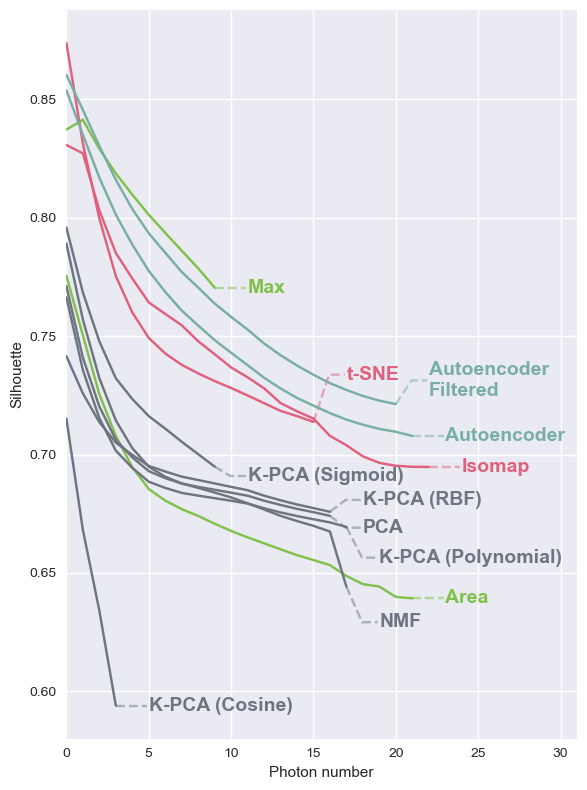

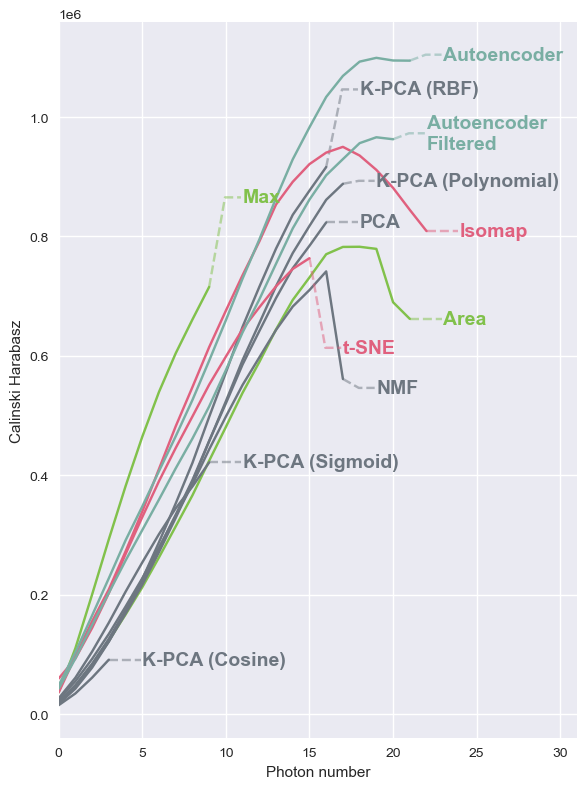

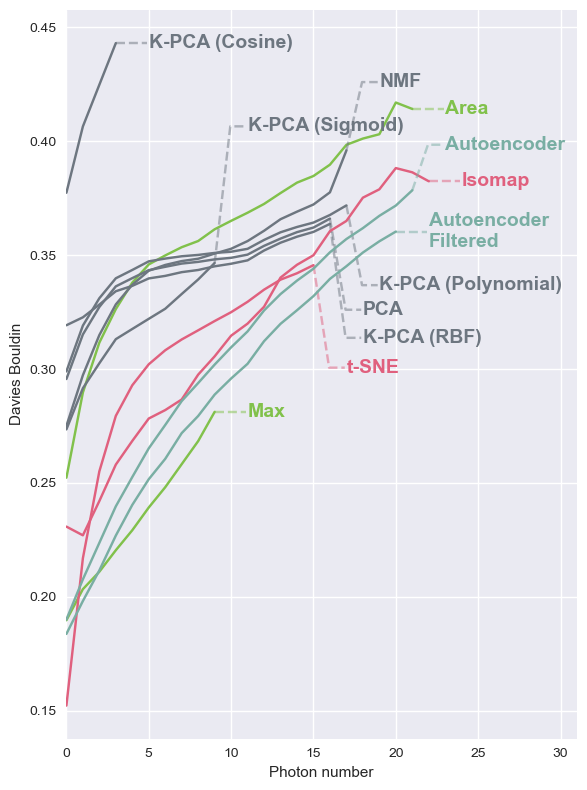

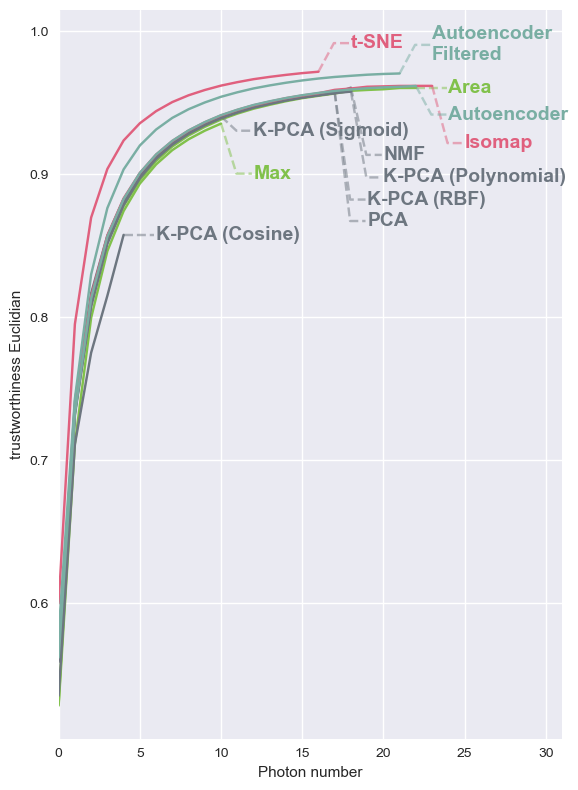

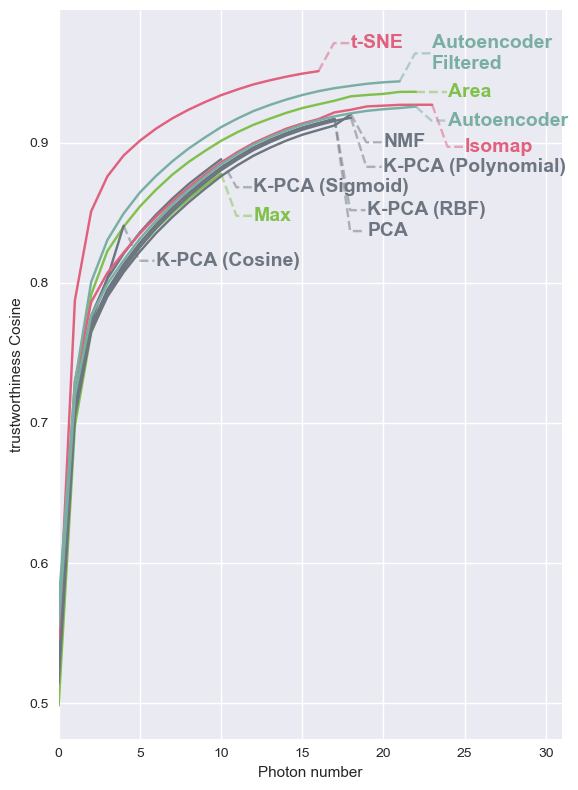

In [27]:
scores = open_object("Metric Log/scores_NIST 2.bin")
metric_list = ['Silhouette','Calinski Harabasz','Davies Bouldin','trustworthiness Euclidian','trustworthiness Cosine']
Title = methods

#colors = get_color_gradient(r"#19889B", r"#F9F871", 10)
GREY98 = "#fafafa"
colors = ["#81C14B", "#81C14B", "#6D7680", "#6D7680", "#6D7680", "#6D7680" , "#6D7680", "#6D7680", "#E0607E", "#E0607E", "#79AEA3", "#79AEA3"]

LABEL_Y = [[# Positions Silhouette
    0,  # Max
    0,  # Area
    -0.005,    # PCA
    -0.013,   # K-PCA (Polynomial)
    0.005,  # K-PCA (RBF)
    -0.004,   # K-PCA (Sigmoid)
    0,  # K-PCA (Cosine)
    -0.015,    # NMF
    0.02,  # t-SNE
    0,  # Isomap
    0,  # Autoencoder
    0.01   # Autoencoder Filter
],
[# Positions Calinski
    0.15e6,  # Max
    0e6,  # Area
    -0.e6,    # PCA
    0.005e6,   # K-PCA (Polynomial)
    0.13e6,  # K-PCA (RBF)
    0e6,   # K-PCA (Sigmoid)
    0e6,  # K-PCA (Cosine)
    -0.015e6,    # NMF
    -0.15e6,  # t-SNE
    0e6,  # Isomap
    0.01e6,  # Autoencoder
    0.01e6   # Autoencoder Filter
],
[# Positions Davies
    0,  # Max
    0,  # Area
    -0.04,    # PCA
    -0.035,   # K-PCA (Polynomial)
    -0.05,  # K-PCA (RBF)
    0.06,   # K-PCA (Sigmoid)
    0,  # K-PCA (Cosine)
    0.03,    # NMF
    -0.045,  # t-SNE
    0,  # Isomap
    0.02,  # Autoencoder
    -0.0   # Autoencoder Filter
],
[# Positions Trust euclidian
    -0.035,  # Max
    0,  # Area
    -0.09,    # PCA
    -0.06,   # K-PCA (Polynomial)
    -0.075,  # K-PCA (RBF)
    -0.01,   # K-PCA (Sigmoid)
    0,  # K-PCA (Cosine)
    -0.047,    # NMF
    0.02,  # t-SNE
    -0.04,  # Isomap
    -0.02,  # Autoencoder
    0.02   # Autoencoder Filter
],
[# Positions Trust Cosine
    -0.03,  # Max
    0,  # Area
    -0.08,    # PCA
    -0.035,   # K-PCA (Polynomial)
    -0.065,  # K-PCA (RBF)
    -0.02,   # K-PCA (Sigmoid)
    -0.025,  # K-PCA (Cosine)
    -0.02,    # NMF
    0.02,  # t-SNE
    -0.03,  # Isomap
    -0.01,  # Autoencoder
    0.02   # Autoencoder Filter
]]

PAD = 0.1


for index_metric, metric_score in enumerate(scores):

    fig, axis = plt.subplots(figsize=(6,8))
    #fig.patch.set_facecolor(GREY98)
    #axis.set_facecolor(GREY98)

    for index_method, method in enumerate(Title):
        sc = scores[index_metric][index_method]
        sc = sc[sc != 0]
        color = colors[index_method]
        y_start = sc[-1]
        y_end = sc[-1] +LABEL_Y[index_metric][index_method]
        x_start = len(sc)-1
        x_end = len(sc)+1

        axis.plot(sc, label=f"{Title[index_method]}", c=color)
        axis.plot([x_start, (x_start + x_end - PAD) / 2 , x_end - PAD], 
                [y_start, y_end, y_end], 
                color=color, 
                alpha=0.5, 
                ls="dashed")
        axis.text(x_end, 
                y_end, 
                Title[index_method], 
                color=color, 
                fontsize=14, 
                weight="bold", 
                va="center")

    axis.set_xlim(0,31)
    axis.set_ylabel(f"{metric_list[index_metric]}")
    axis.set_xlabel('Photon number')
    plt.tight_layout()
    plt.show()